## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## 2. Load the Dataset

In [4]:
df_country = pd.read_csv('Country-data.csv')
df_dictionary = pd.read_csv('data-dictionary.csv')

In [5]:
df_dictionary

,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services per capita. Give...
3,health,Total health spending per capita. Given as %ag...
4,imports,Imports of goods and services per capita. Give...
5,Income,Net income per person
6,Inflation,The measurement of the annual growth rate of t...
7,life_expec,The average number of years a new born child w...
8,total_fer,The number of children that would be born to e...
9,gdpp,The GDP per capita. Calculated as the Total GD...


In [6]:
df_country.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [7]:
print("Shape of country Dataset:", df_country.shape)
df_country.info()
display(df_country.describe(include='all').T)

                    

Shape of country Dataset: (167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


## 3. Data Cleaning

In [9]:
df_country.columns = [col.strip().lower() for col in df_country.columns]
numeric_features = [c for c in df_country.columns if c != 'country']

# Handle missing gaps using robust robust median imputation
df_country[numeric_features] = df_country[numeric_features].fillna(df_country[numeric_features].median())

print(f"Dataset Structure: {df_country.shape[0]} Countries, {df_country.shape[1]} Features")

Dataset Structure: 167 Countries, 10 Features


## 4. Exploratory Data Analysis

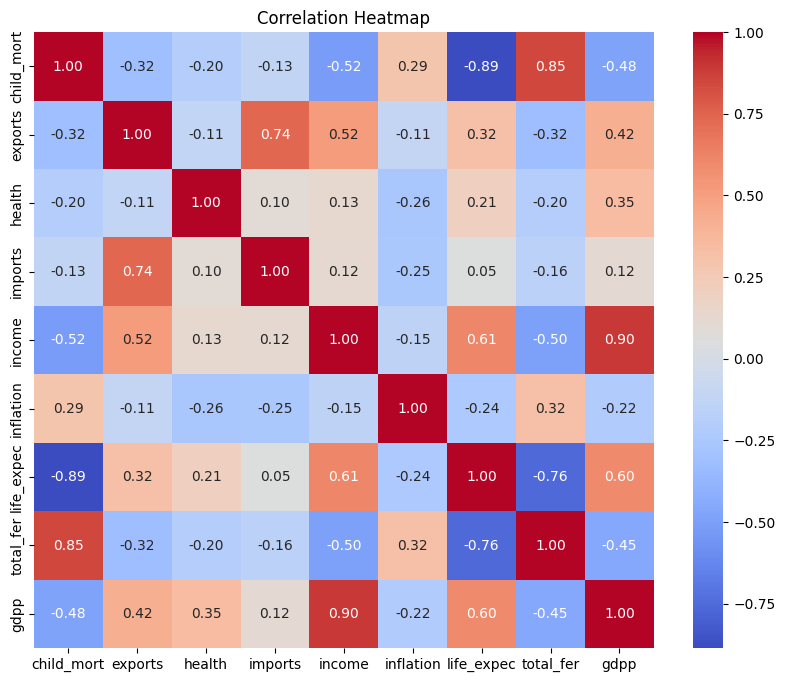

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_country.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

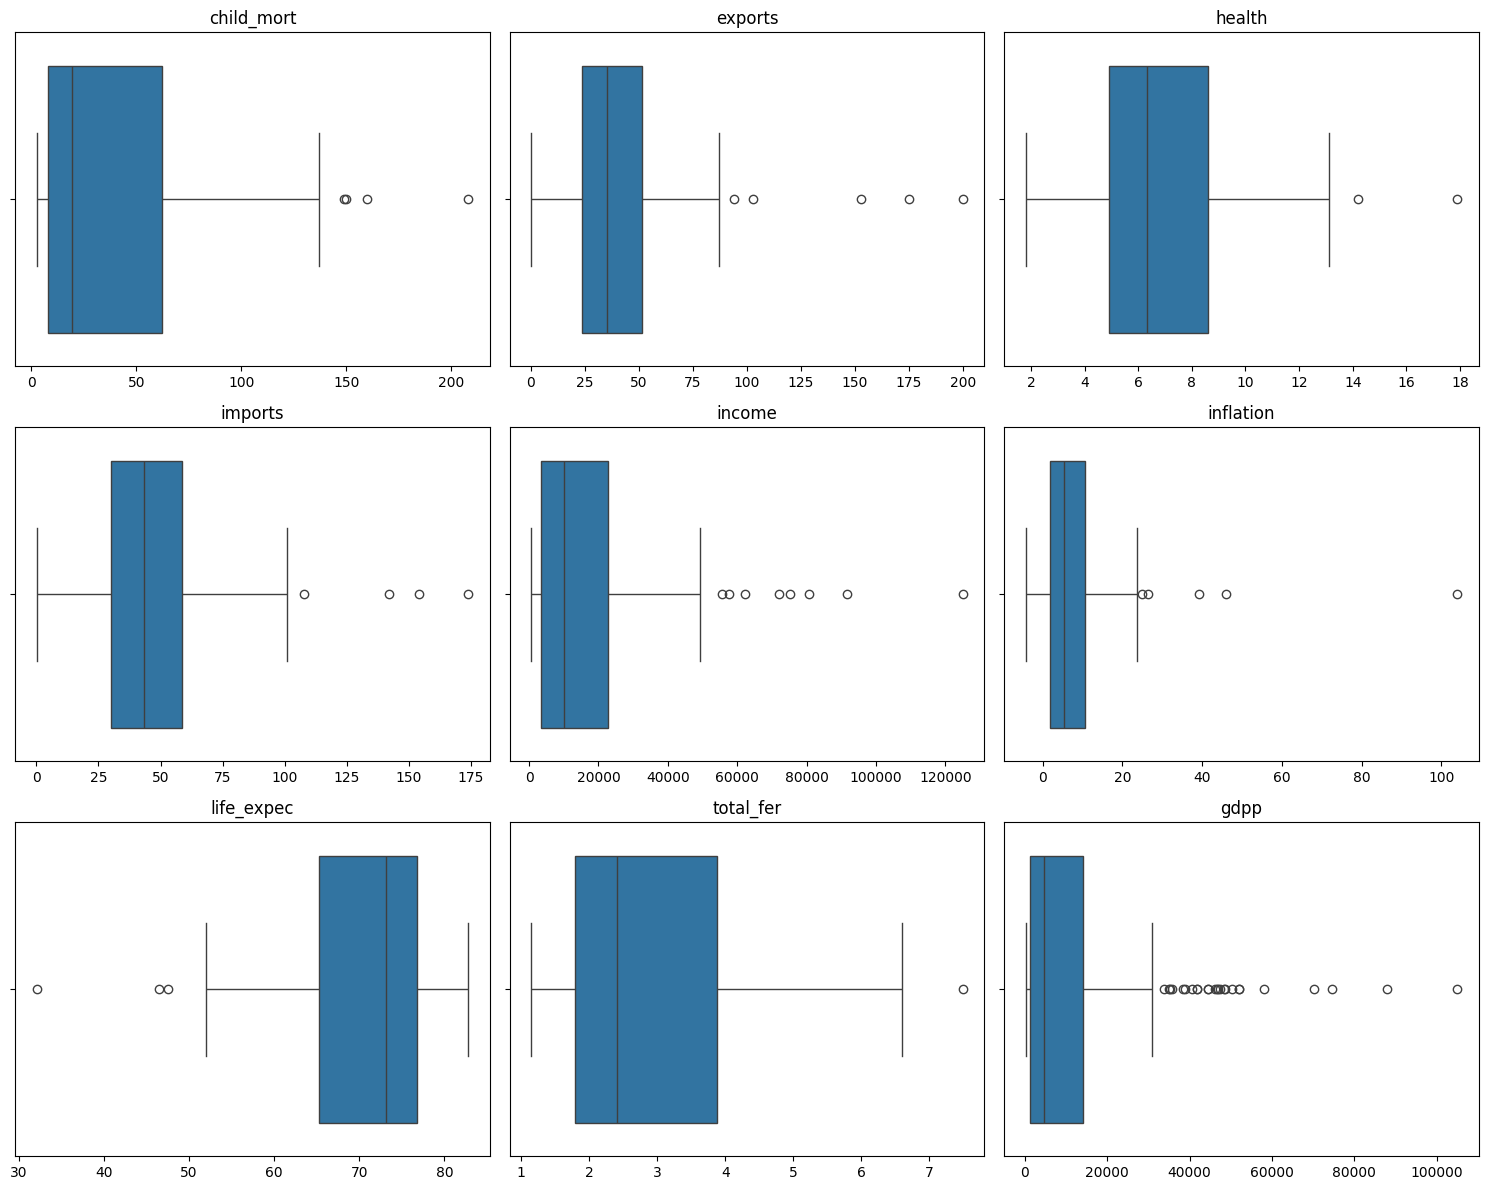

In [22]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    sns.boxplot(x=df_country[col], ax=axes[i])  
    axes[i].set_title(f'{col}')                 # Set the title for that box
    axes[i].set_xlabel('')                      # Remove x-label to keep it clean

plt.tight_layout()
plt.show()

## 5. Feature Scaling

In [25]:
# Transform and standardize numerical footprints
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_country[numeric_features])

# Convert back to structured DataFrame context
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_features)

## 6. K-Means

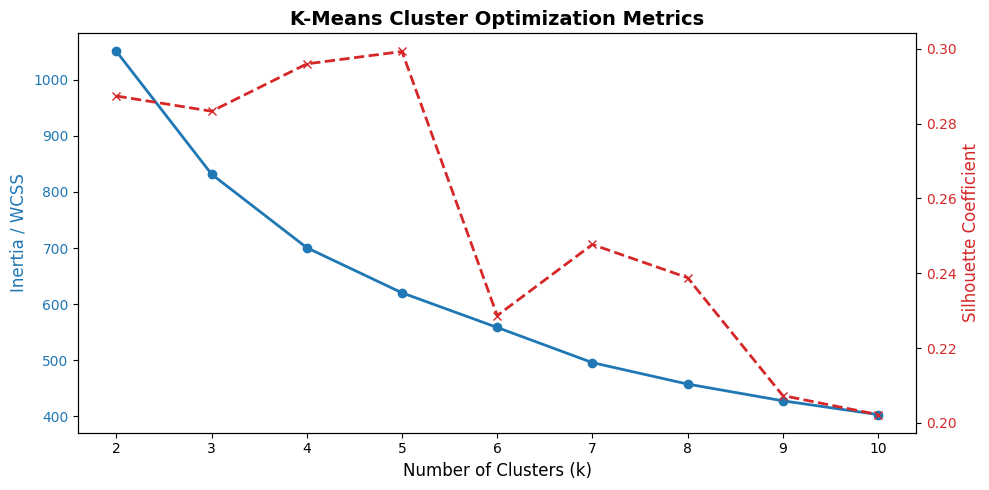

In [28]:
inertias = []
silhouette_avg = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(X_scaled, labels))

# Plot performance indicators simultaneously
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia / WCSS', color=color, fontsize=12)
ax1.plot(k_range, inertias, color=color, marker='o', linewidth=2, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Silhouette Coefficient', color=color, fontsize=12)
ax2.plot(k_range, silhouette_avg, color=color, marker='x', linestyle='--', linewidth=2, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('K-Means Cluster Optimization Metrics', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

In [30]:
# Initialize and apply final optimized model
optimal_k = 3
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_assignments = final_kmeans.fit_predict(X_scaled)

# Append strategic targets back to regional records
df_country['cluster_id'] = cluster_assignments

# Extract target profile matrix values across distinct groups
cluster_profiles = df_country.groupby('cluster_id')[numeric_features].mean().reset_index()
display(cluster_profiles)

,cluster_id,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


## 7. PCA

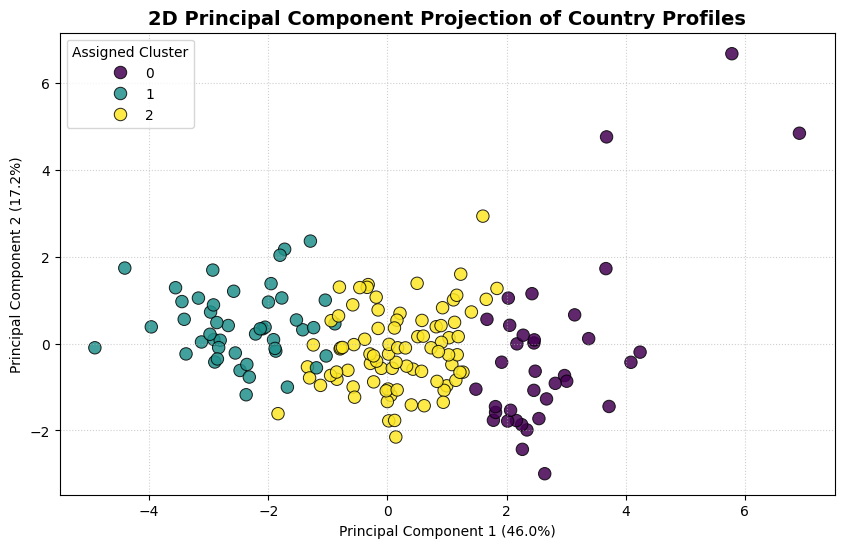

In [33]:
# Project down to principal linear coordinate planes
pca_transform = PCA(n_components=2, random_state=42)
X_pca = pca_transform.fit_transform(X_scaled)

# Build a plotting framework
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = cluster_assignments

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_pca, x='PC1', y='PC2', hue='Cluster', 
    palette='viridis', s=80, edgecolor='black', alpha=0.85
)
plt.title('2D Principal Component Projection of Country Profiles', fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({pca_transform.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca_transform.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Assigned Cluster')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## 8. Train K Means

In [36]:
best_k = 3  # change after checking the elbow plot
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_country['cluster_id'] = kmeans.fit_predict(X_scaled)

print('Silhouette Score:', silhouette_score(X_scaled, df_country['cluster_id']))
df_country[['country', 'cluster_id']].head() if 'country' in df_country.columns else df_country[['cluster_id']].head()

Silhouette Score: 0.28329575683463126


,country,cluster_id
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


## 9. DBSCAN

In [39]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df_country['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(df_country['dbscan_cluster'].value_counts().sort_index())

dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64


## 10. Cluster Profile

In [42]:
profile = df_country.groupby('cluster_id')[numeric_features].mean()
profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster_id,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381



##  Write 3 to 5 observations about the clusters:
- Which cluster has high child mortality?
- Which cluster has high income and gdpp?
- Which cluster looks underdeveloped?
- Which countries should be prioritized for aid?
- Find cluster of India

In [45]:

high_child_mort_cluster = profile['child_mort'].idxmax()
highest_val = profile['child_mort'].max()

print(f"Cluster with highest child mortality: Cluster {high_child_mort_cluster}")
print(f"Average Child Mortality Rate for this cluster: {highest_val:.2f} per 1000 live births")

Cluster with highest child mortality: Cluster 1
Average Child Mortality Rate for this cluster: 92.96 per 1000 live births


In [47]:
# Cluster with highest income
high_income_cluster = profile['income'].idxmax()
print("Cluster with highest income:", high_income_cluster)

# Cluster with highest GDPP
high_gdpp_cluster = profile['gdpp'].idxmax()
print("Cluster with highest GDPP:", high_gdpp_cluster)

Cluster with highest income: 0
Cluster with highest GDPP: 0


In [49]:
# Underdeveloped cluster
underdeveloped_cluster = profile['gdpp'].idxmin()
print("Most underdeveloped cluster:", underdeveloped_cluster)

Most underdeveloped cluster: 1


In [51]:
# 1. Identify the underdeveloped cluster programmatically based on highest child mortality
underdeveloped_cluster = df_country.groupby('cluster_id')['child_mort'].mean().idxmax()

# 2. Filter the countries that belong to this high-priority cluster
priority_countries = df_country[df_country['cluster_id'] == underdeveloped_cluster]['country']

print(f"Countries to prioritize for aid (Cluster {underdeveloped_cluster}):")
print(priority_countries.tolist())

Countries to prioritize for aid (Cluster 1):
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Iraq', 'Kenya', 'Kiribati', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda', 'Senegal', 'Sierra Leone', 'South Africa', 'Sudan', 'Tanzania', 'Timor-Leste', 'Togo', 'Uganda', 'Yemen', 'Zambia']


In [53]:
# find cluster of india
india_cluster = df_country[df_country['country'] == 'India']['cluster_id'].values[0]
print("India belongs to cluster:", india_cluster)

India belongs to cluster: 2


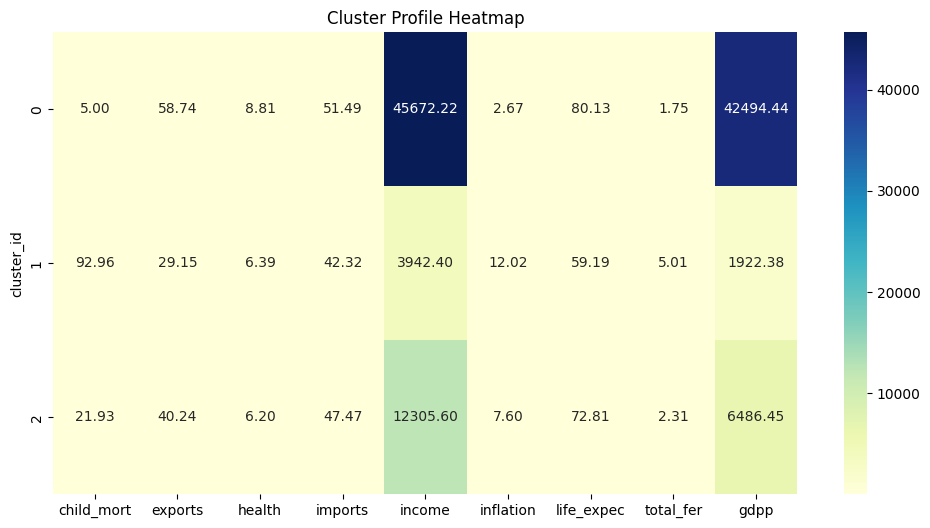

In [54]:
 
plt.figure(figsize=(12,6))
sns.heatmap(profile, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Cluster Profile Heatmap')
plt.show()

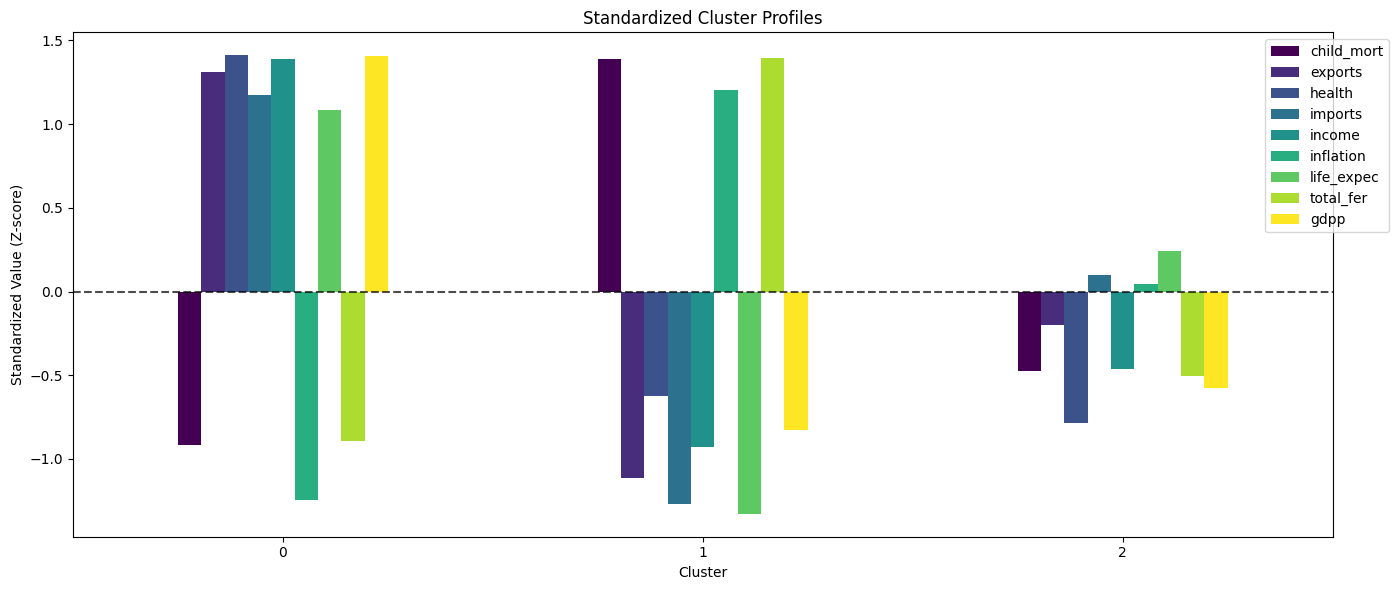

In [56]:
# Standardize the cluster profile
scaler = StandardScaler()

profile_scaled = pd.DataFrame(
    scaler.fit_transform(profile),
    columns=profile.columns,
    index=profile.index
)

# Plot standardized profile
profile_scaled.plot(
    kind='bar',
    figsize=(14,6),
    colormap='viridis'
)

plt.title('Standardized Cluster Profiles')
plt.ylabel('Standardized Value (Z-score)')
plt.xlabel('Cluster')
plt.xticks(rotation=0)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()